# Imports

In [5]:
%cd /home/e12009247/CHARLX_TS/charlx_ts

/home/e12009247/CHARLX_TS/charlx_ts


In [6]:
!pwd

/home/e12009247/CHARLX_TS/charlx_ts


/home/e12009247/miniconda3/envs/cx/lib/python3.12/pty.py:95: RuntimeWarning: os.fork() was called. os.fork() is incompatible with multithreaded code, and JAX is multithreaded, so this will likely lead to a deadlock.
  pid, fd = os.forkpty()


In [ ]:
import os
import warnings

warnings.filterwarnings("ignore", module="e3nn")
warnings.filterwarnings("ignore", module="torch")
warnings.simplefilter(action="ignore", category=FutureWarning)
warnings.simplefilter(action="ignore", category=UserWarning)

import pathlib
import random
import shutil

import jax
import matplotlib.pyplot as plt
import numpy as np
import torch

from ase import Atoms
from ase.io import read
from ase.io.jsonio import encode
from ase.visualize.plot import plot_atoms

from sella import IRC

from mace.calculators import MACECalculator

from condevo.es.guidance import KNNNoveltyCondition

from cluster import load_lj_cluster, evaluate_lj_population_torch
from charlx import AtomsFixer, AtomsRelaxer, AtomsTSOptimizer, CHARLX
from condition import OriginCondition
from run import CorrectedApplyLimitsObjective, run_evo
from ase.visualize import view
from view import view_results
from util import check_saddle_point

torch.set_default_dtype(torch.float64)

SEED = 0
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED);


def plot_atoms_without_axes(atoms, radii=None, rotation=None):
    fig, ax = plt.subplots()
    plot_atoms(atoms, ax=ax, radii=radii, rotation=rotation);
    ax.axis("off")



cuequivariance or cuequivariance_torch is not available. Cuequivariance acceleration will be disabled.


### helper funcs

In [2]:
from ase.vibrations import Vibrations
import h5py

# function that follows internal reaction coordinate towards minima in both directions
def run_irc(atoms : Atoms, dx : float = 0.1, steps : int = 1000):
    ts_atoms = atoms.copy()
    ts_atoms.calc = atoms.calc

    min_energies = []
    

    irc_fw = IRC(ts_atoms, dx=dx, trajectory="irc_fw.traj")

    irc_fw.run(steps=steps, direction="forward");

    min_energies.append(ts_atoms.get_potential_energy())
    min_state_1 = ts_atoms.copy()

    ts_atoms.set_positions(atoms.get_positions())
    irc_bw = IRC(ts_atoms, dx=dx, trajectory="irc_bw.traj")
    irc_bw.run(steps=steps, direction="reverse");

    min_energies.append(ts_atoms.get_potential_energy())
    min_state_2 = ts_atoms.copy()

    return min_energies, min_state_1, min_state_2


def plot_sella_irc(fwd_traj, bwd_traj):
    """
    Combines forward and backward IRC trajectories for a complete plot.
    """
    fwd_configs = read(fwd_traj, index=':')
    bwd_configs = read(bwd_traj, index=':')
    
    # Reverse backward configs so they lead TO the TS
    full_path = bwd_configs[::-1] + fwd_configs[1:]
    
    energies = [at.get_potential_energy() for at in full_path]
    # Use absolute energies (could also be normalized)
    energies = np.array(energies) # - energies[0]
    
    steps = np.arange(len(full_path))
    
    plt.figure(figsize=(8, 5))
    plt.plot(steps, energies, color='#1f77b4', lw=2)
    plt.scatter(steps, energies, c=energies, cmap='viridis')
    
    # Find the peak (the TS)
    ts_idx = np.argmax(energies)
    plt.annotate(f'{energies[ts_idx]:.4f} eV', xy=(ts_idx, energies[ts_idx]), 
             xytext=(ts_idx-1, energies[ts_idx]-0.1))
    
    min1_idx = 0
    plt.annotate(f'{energies[min1_idx]:.4f} eV', xy=(min1_idx, energies[min1_idx]), 
             xytext=(min1_idx-1, energies[min1_idx]+0.1))
    
    min2_idx = len(energies) - 1
    plt.annotate(f'{energies[min2_idx]:.4f} eV', xy=(min2_idx, energies[min2_idx]), 
             xytext=(min2_idx-1, energies[min2_idx]+0.1))

    plt.title("IRC Energy Profile")
    plt.xlabel("Step Number")
    plt.ylabel("Energy (eV)")
    plt.grid(True, alpha=0.3)
    plt.show()


### testing sella, TS opt

In [7]:
N_ATOMS = 7

seeds = [123]

opt_structs = []
opt_data = []

import gc
import glob
import os

for i, seed in enumerate(seeds):

    print(f"\n{'='*70}")
    print(f"Iteration {i+1}/{len(seeds)} - Seed {seed}")
    print(f"{'='*70}")

    gc.collect()
    
    # Clean up any temporary files from previous iteration
    for pattern in ['vib_*', 'ts_check*', 'ts_scan*']:
        for f in glob.glob(pattern):
            try:
                if os.path.isfile(f):
                    os.remove(f)
                elif os.path.isdir(f):
                    shutil.rmtree(f)
            except:
                pass

    # Initialize founder structure
    lj_cluster_rand, max_span, dimensions, symbols, rep = load_lj_cluster(
        n_atoms=N_ATOMS,
        wales_path=pathlib.Path("data/wales"),
        randomize=True,
        random_seed=seed,
    )
    founder = Atoms(symbols, np.reshape(lj_cluster_rand, (-1, 3)))

    from ase.calculators.lj import LennardJones
    founder.calc = LennardJones(sigma=1 / (2 ** (1.0 / 6.0)), rc=10.0, smooth=True)

    fixer = AtomsFixer(
        fix_func="get_fixed_by_list",
        fix_list=[],
        fix_axis=None,
        fix_threshold=None,
    )

    opt_atoms = founder.copy()

    steps = 5000

    opt_atoms.calc = LennardJones(sigma=1 / (2 ** (1.0 / 6.0)), rc=10.0, smooth=True)

    ts_optimizer = AtomsTSOptimizer(
        founder_atoms=opt_atoms,
        fixer=fixer,
        calc="LJ",
        fmax=1e-3,
        steps=steps,
        logfile=None,
        multiproc=True,
        n_proc=16,
        device="cpu",
        e_cutoff=-500,
        progress_bar=True,
    )

    opt_atoms = ts_optimizer.optimize_atoms(opt_atoms, steps)
    opt_atoms.calc = LennardJones(sigma=1 / (2 ** (1.0 / 6.0)), rc=10.0, smooth=True)

    opt_structs.append(opt_atoms)
    opt_data.append(check_saddle_point(opt_atoms))


Iteration 1/1 - Seed 123


     Step     Time          Energy          fmax
IRC:    0 13:54:22      -14.596946        0.000300
IRC:    1 13:54:22      -14.597220        0.023858
IRC:    2 13:54:22      -14.598041        0.047608
IRC:    3 13:54:22      -14.599407        0.071575
IRC:    4 13:54:22      -14.601322        0.095694
IRC:    5 13:54:22      -14.603792        0.120380
IRC:    6 13:54:22      -14.606824        0.145568
IRC:    7 13:54:22      -14.610430        0.171460
IRC:    8 13:54:22      -14.614623        0.198159
IRC:    9 13:54:22      -14.619421        0.225847
IRC:   10 13:54:22      -14.624844        0.254661
IRC:   11 13:54:22      -14.630914        0.284774
IRC:   12 13:54:22      -14.637657        0.316353
IRC:   13 13:54:22      -14.645104        0.349566
IRC:   14 13:54:22      -14.653287        0.384634
IRC:   15 13:54:22      -14.662244        0.421688
IRC:   16 13:54:22      -14.672016        0.461067
IRC:   17 13:54:22      -14.682647        0.502774
IRC:   18 13:54:22      -14.69418

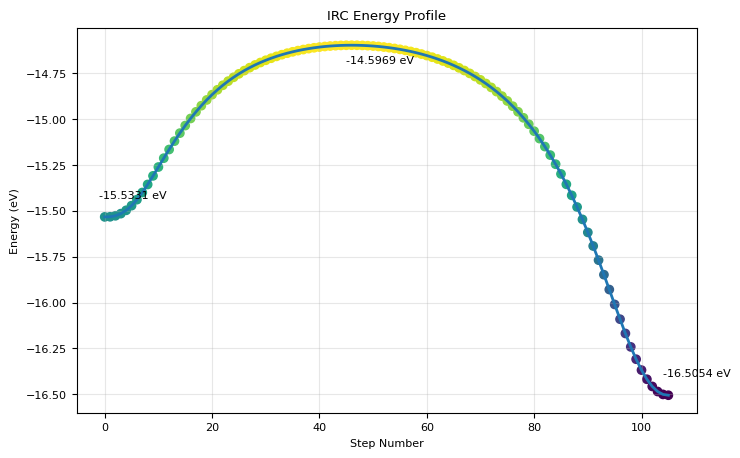

In [8]:
ts_state = opt_structs[0]
_, min1, min2 = run_irc(ts_state, steps=100)

plot_sella_irc("irc_fw.traj", "irc_bw.traj")

In [9]:
check_saddle_point(ts_state), ts_state.get_potential_energy()

({'is_saddle_point': True,
  'n_imaginary_freqs': 5,
  'imaginary_freq_val': np.complex128(123.135450160261j),
  'all_freqs_cm1': array([   0.   +123.135j,    0.    +19.113j,    0.    +17.254j,
            0.    +15.156j,    0.     +0.j   ,    0.     +0.j   ,
            0.     +0.j   ,  343.369  +0.j   ,  485.388  +0.j   ,
          640.87   +0.j   ,  692.807  +0.j   ,  802.482  +0.j   ,
          872.858  +0.j   ,  934.872  +0.j   ,  989.642  +0.j   ,
         1060.77   +0.j   , 1100.267  +0.j   , 1237.743  +0.j   ,
         1306.288  +0.j   , 1451.383  +0.j   , 1559.118  +0.j   ]),
  'n_negative_evals': 1,
  'raw_eigenvalues': array([-2.22700e+00, -5.40000e-02, -4.40000e-02, -3.40000e-02,
         -0.00000e+00,  0.00000e+00,  0.00000e+00,  1.73200e+01,
          3.46110e+01,  6.03360e+01,  7.05110e+01,  9.46030e+01,
          1.11924e+02,  1.28392e+02,  1.43877e+02,  1.65302e+02,
          1.77841e+02,  2.25059e+02,  2.50676e+02,  3.09456e+02,
          3.57102e+02]),
  'lowest_eval

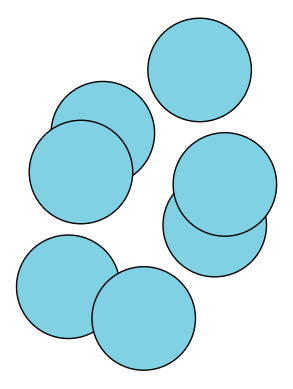

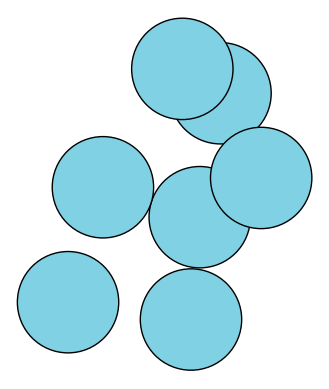

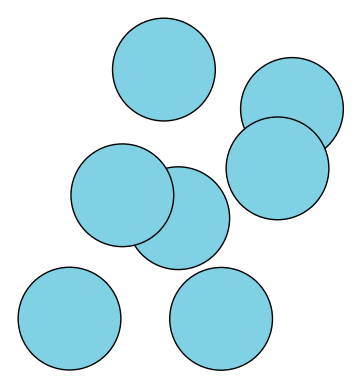

In [36]:
rotation = ""
radii = 0.3
plot_atoms_without_axes(min1, radii=radii, rotation=rotation)
plot_atoms_without_axes(ts_state, radii=radii, rotation=rotation),
plot_atoms_without_axes(min2, radii=radii, rotation=rotation)

In [38]:
ts_state

Atoms(symbols='Ar7', pbc=False, calculator=LennardJones(...))

In [41]:
view(ts_state)

<Popen: returncode: None args: ['/opt/anaconda3/envs/cx/bin/python', '-m', '...>

## 1. Lennard-Jones (LJ) cluster

The first example is a CHARLX evolution of the Lennard-Jones cluster with 13 atoms (LJ-13). The coordinates for the global minimum are loaded from files saved in the directory `data/wales/`. Files for clusters with 13, 31 and 38 atoms are available, other files with clusters up to 150 atoms can be downloaded as a `.tar` file from `https://doye.chem.ox.ac.uk/jon/structures/LJ/tables.150.html`. After loading, additional information is shown: `max_span` (the maximum span of the structure used for conditioning), `dimensions` (number of atoms times three), `symbols` (chemical symbols for the `ase.atoms.Atoms` object) and `rep` (string representation for the destination path of the evolution). Also given is the energy of the structure, calculated by the `evaluate_lj_population_torch()` function, together with a visualiation of the cluster. For an interactive plot, comment in the last line `view(lj_atoms);`.

### Founder

We can now start with the configuration of the evolution. First, we define the randomized LJ-13 cluster from above as the `founder` structure for our evolution.

In [10]:
N_ATOMS = 7 # 13, 31, 38

# Initialize founder structure
lj_cluster_rand, max_span, dimensions, symbols, rep = load_lj_cluster(
    n_atoms=N_ATOMS,
    wales_path=pathlib.Path("data/wales"),
    randomize=True,
    random_seed=0,
)


au_cluster_rand, max_span, dimensions, symbols, rep = load_lj_cluster(
    n_atoms=N_ATOMS,
    wales_path=pathlib.Path("data/wales"),
    randomize=True,
    random_seed=SEED,
    element="Au",
    name="Au",
)


founder = Atoms(symbols, np.reshape(lj_cluster_rand, (-1, 3)))

#plot_atoms_without_axes(founder)

In [ ]:
# Detect available device
USE_GPU = len(jax.devices('gpu')) > 0
DEVICE = "cuda" if USE_GPU else "cpu"
MULTIPROC = not USE_GPU  # Disable multiprocessing when using GPU

print(f"Using device: {DEVICE}")
print(f"Multiprocessing: {MULTIPROC}")

# Initialize fixing parameters
fixer = AtomsFixer(
    fix_func="get_fixed_by_list",
    fix_list=[],
    fix_axis=None,
    fix_threshold=None,
)

fixed_indices, frozen_indices, free_indices = fixer.get_indices(founder)



# Initialize relaxing parameters
relaxer = AtomsRelaxer(
    founder_atoms=founder,
    fixer=fixer,
    calc="LJ",
    optimizer="FIRE",
    fmax=0.001,
    steps=1000,
    logfile=None,
    multiproc=MULTIPROC,
    n_proc=16,
    device=DEVICE,
    e_cutoff=-500,
    progress_bar=True,
)

####################################
# Initialize TS optimizer
ts_optimizer = AtomsTSOptimizer(
    founder_atoms=founder,
    fixer=fixer,
    calc="LJ",
    #calc="mace/mace-omat-0-medium.model",
    fmax=0.001,
    steps=10,
    logfile=None,
    multiproc=MULTIPROC,
    n_proc=16,
    device=DEVICE,
    e_cutoff=-500,
    progress_bar=True,
)


# Initialize condition around the origin
condition_obj = OriginCondition(
    n_atoms=ts_optimizer.free_n_atoms,
    target=1.0,
    kwargs={"cond_threshold": max_span},
)

# Initialize evolutionary algorithm
es = CHARLX
es_config = dict(
    x0=ts_optimizer.free_positions,
    fixer=fixer,
    #relaxer=relaxer,
    ts_optimizer=ts_optimizer,
    conditions=(condition_obj, KNNNoveltyCondition()),
    popsize=32,
    n_gens=10,
    sigma_init=0.1,
    selection_pressure=20.0,
    elite_ratio=0.15,
    crossover_ratio=0.125,
    mutation_rate=0.05,
    diff_batch_size=256,
    diff_max_epoch=1000,
    buffer_size=1000,
    is_genetic_algorithm=True,
    adaptive_selection_pressure=True,
    readaptation=False,
    forget_best=False,
)

# Initialize neural network
nn = "MLP"
nn_config = dict(
    num_hidden=96,
    num_layers=8,
    activation="LeakyReLU",
    num_params=relaxer.dimensions,
    num_conditions=len(es_config["conditions"]),
)

# Initialize diffusion model
diff = "GGDDIM"
diff_config = dict(
    num_steps=5000,
    lamba_range=1.0,
    geometry="radial",
    axis=None,
    lower_threshold=0.0,
    upper_threshold=max_span*1.5,
    diff_origin=[0.0, 0.0, 0.0],
    overlap_penalty=True,
    train_on_penalty=True,
)

"""
# ENERGY MIN OBJECTIVE
energy_objective = CorrectedApplyLimitsObjective(
    foo_module="util",
    foo="evaluate_population_with_calc",
    foo_kwargs={"obj_params": relaxer.encode_params()},
    maximize=True,
    dim=relaxer.dimensions,
)"""

# EIGENVALUE OBJECTIVE
eigenval_objective = CorrectedApplyLimitsObjective(
    foo_module="util",
    foo="minimize_eigenval",
    foo_kwargs={"obj_params": ts_optimizer.encode_params()},
    maximize=True,
    dim=ts_optimizer.dimensions,
)

In [15]:
# Define destination path for output data
dst = f"output/{rep}"
dst += f"_P-{es_config["popsize"]}"
dst += f"_G-{es_config["n_gens"]}"
dst += f"_F-{ts_optimizer.fmax}"
dst += f"_S-{ts_optimizer.steps}"
dst += f"_U-{diff_config['upper_threshold']:.3f}"

In [16]:
# Remove old folder before new evolution
shutil.rmtree(dst, ignore_errors=True)

# Execute CHARLX evolution
evo = run_evo(
    generations=es_config["n_gens"],
    es=es,
    es_config=es_config,
    nn=nn,
    nn_config=nn_config,
    diff=diff,
    diff_config=diff_config,
    objective=eigenval_objective,
    dst=dst,
    params={"save_diffusion": False},
)


# Loading Objective:
<class 'run.CorrectedApplyLimitsObjective'> True
-  {"dim": 21, "foo_module": "util", "foo_kwargs": {"obj_params": {"founder_atoms": "{\"numbers\": {\"__ndarray__\": [[7], \"int64\", [79, 79, 79, 79, 79, 79, 79]]}, \"positions\": {\"__ndarray__\": [[7, 3], \"float64\", [-0.8123409842682983, -0.9446405163550983, 0.643662337802372, -0.10776427680085379, 0.8623342540419481, 0.07611414011399295, 0.7067941930318545, 0.18608956317024505, 1.2905390185305972, 0.9789043480337464, 0.10202249539452755, 0.8020181452954087, 0.042181069400926335, -0.10045625855391703, -1.0367215671569265, 0.6977301252087114, -0.42602988796896785, 0.8356198686211064, -0.13409414779755607, -0.10623934165632305, -0.44290510087411716]]}, \"cell\": {\"__ndarray__\": [[3, 3], \"float64\", [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]]}, \"pbc\": {\"__ndarray__\": [[3], \"bool\", [false, false, false]]}, \"__ase_objtype__\": \"atoms\"}", "fixed_atoms": "null", "frozen_atoms": "null", "free_atoms": "{\"

TS Optimization:   0%|          | 0/32 [00:00<?, ?it/s]2026-03-09 14:42:07.029993: W external/xla/xla/service/gpu/ir_emitter_unnested.cc:1171] Unable to parse backend config for custom call: Could not convert JSON string to proto: Expected : between key:value pair.
= 0 : ui8, lower = t
^
Fall back to parse the raw backend config str.
2026-03-09 14:42:07.039080: W external/xla/xla/service/gpu/ir_emitter_unnested.cc:1171] Unable to parse backend config for custom call: Could not convert JSON string to proto: Expected : between key:value pair.
= true, full_matrice
^
Fall back to parse the raw backend config str.
2026-03-09 14:42:07.449790: W external/xla/xla/service/gpu/ir_emitter_unnested.cc:1171] Unable to parse backend config for custom call: Could not convert JSON string to proto: Expected : between key:value pair.
= 0 : ui8, lower = t
^
Fall back to parse the raw backend config str.
2026-03-09 14:42:08.373887: W external/xla/xla/service/gpu/ir_emitter_unnested.cc:1171] Unable to pars

  { "Generation": 0, "Max-Fitness": 449249.81520790333, "Avg-Fitness": 16832.9813382656, "Model-Loss": 0.15403049772676272}



Training Diffusion Model: 100%|██████████| 1000/1000 [00:06<00:00, 162.20epoch/s, loss=0.161]


  { "Generation": 1, "Max-Fitness": 43088.22430909637, "Avg-Fitness": 2166.283453782566, "Model-Loss": 0.16051770546886268}


...


Training Diffusion Model: 100%|██████████| 1000/1000 [00:05<00:00, 170.70epoch/s, loss=0.151]


  { "Generation": 8, "Max-Fitness": 25.41628109708182, "Avg-Fitness": 13.458985353047291, "Model-Loss": 0.1507116961685808}


Training Diffusion Model: 100%|██████████| 1000/1000 [00:10<00:00, 98.53epoch/s, loss=0.149] 

  { "Generation": 9, "Max-Fitness": 74.19604337491229, "Avg-Fitness": 13.7642045668969, "Model-Loss": 0.14907935526175406}


  { "Generation": 9, "Max-Fitness": 74.19604337491229, "Avg-Fitness": 13.7642045668969, "Model-Loss": 0.14907935526175406}


### View results

In [18]:
from ase.io.jsonio import decode
import h5py


def analyze_es_energy_groups(h5_filename, run_id=0, obj_params=None, energy_tolerance=0.01, plot=True):
    """
    Analyzes ES results by grouping structures with similar energy levels.
    Calculates actual eigenvalues from structures if obj_params provided, otherwise uses fitness.
    
    Args:
        h5_filename: Path to HDF5 output file from run_evo()
        run_id: Run ID to analyze (default: 0 for first run)
        obj_params: dict with structure parameters (founder_atoms, fixed_atoms, free_atoms, etc.)
                   If provided, actual eigenvalues will be calculated
        energy_tolerance: Energy threshold (in eV) for grouping similar structures
        plot: Whether to plot the results
    
    Returns:
        Dictionary with analysis of energy groups
    """
    with h5py.File(h5_filename, 'r') as f:
        run_group = f[f'run_{run_id}']
        
        all_fitness = []
        best_fitness_per_gen = []
        all_samples = []
        
        # Iterate through generations
        n_gens = len([k for k in run_group.keys() if k.startswith('gen_')])
        
        for gen_idx in range(n_gens):
            gen_group = run_group[f'gen_{gen_idx}']
            fitness = gen_group['fitness'][:]
            samples = gen_group['samples'][:]
            
            # Use negative fitness (actual minimization direction)
            all_fitness.extend(-fitness)
            all_samples.append(samples)
            best_fitness_per_gen.append(-np.max(fitness))
        
        all_fitness = np.array(all_fitness)
        all_samples = np.concatenate(all_samples, axis=0)
    
    # If obj_params provided, calculate actual energies from structures
    if obj_params is not None:
        print("Calculating actual energies from structures...")
        founder_atoms = decode(obj_params["founder_atoms"])
        fixed_atoms = decode(obj_params["fixed_atoms"])
        free_atoms = decode(obj_params["free_atoms"])
        
        frozen_atoms_raw = obj_params.get("frozen_atoms", None)
        frozen_atoms = decode(frozen_atoms_raw) if frozen_atoms_raw is not None else None
        frozen_indices = obj_params.get("frozen_indices", [])
        free_indices = obj_params.get("free_indices")
        
        from util import init_calc, solutions_to_atoms_list, calc_atoms_list, get_lowest_eigenvalue, get_potential_energy
        calc = init_calc(obj_params["calc"], obj_params["device"])
        
        atoms_list = solutions_to_atoms_list(
            solutions=all_samples,
            founder_atoms=founder_atoms,
            fixed_atoms=fixed_atoms,
            fixed_indices=obj_params["fixed_indices"],
            free_atoms=free_atoms,
            calc=calc,
            frozen_atoms=frozen_atoms,
            frozen_indices=frozen_indices,
        )
        
        energies = calc_atoms_list(
            atoms_list,
            func=get_potential_energy,
            desc="Calculating energies",
            multiproc=obj_params["multiproc"],
            n_proc=obj_params["n_proc"],
            progress_bar=obj_params["progress_bar"],
            kwargs={},
        )
        
        all_energies = np.array(energies)
    
    # Group structures by similar energy levels
    energy_groups = []
    sorted_indices = np.argsort(all_energies)  # Sort lowest energy first
    
    for idx in sorted_indices:
        energy = all_energies[idx]
        
        # Check if this energy belongs to any existing group
        assigned = False
        for group_energy, group_indices in energy_groups:
            if abs(energy - group_energy) < energy_tolerance:
                assigned = True
                group_indices.append(idx)
                break
        
        if not assigned:
            # Create new energy group
            energy_groups.append((energy, [idx]))
    
    print(f"\n{'='*70}")
    print(f"Energy Group Analysis - Run {run_id}")
    print(f"{'='*70}")
    print(f"Total samples evaluated: {len(all_fitness)}")
    print(f"Energy groups found: {len(energy_groups)}")
    print(f"Energy tolerance: {energy_tolerance} eV")
    print(f"\nEnergy groups (sorted by energy):")
    print(f"{'Rank':<6} {'Energy (eV)':<18} {'Count':<8} {'Frequency':<12}")
    print(f"{'-'*70}")
    
    for rank, (energy, indices) in enumerate(energy_groups, 1):
        count = len(indices)
        frequency = count / len(all_fitness) * 100
        print(f"{rank:<6} {energy:<18.6f} {count:<8} {frequency:>6.2f}%")
    
    print(f"{'='*70}\n")
    
    if plot:
        fig, axes = plt.subplots(2, 2, figsize=(12, 10))
        
        # Plot 1: All fitness histogram
        ax = axes[0, 0]
        ax.hist(all_fitness, bins=30, color='steelblue', alpha=0.7, edgecolor='black')
        ax.set_xlabel('Energy (eV)')
        ax.set_ylabel('Count')
        ax.set_title('Distribution of All Samples (Fitness)' if obj_params else 'Distribution of All Samples (Fitness)')
        ax.grid(True, alpha=0.3)
        
        # Plot 2: Best Fitness per generation
        ax = axes[0, 1]
        ax.plot(best_fitness_per_gen, 'o-', color='darkgreen', linewidth=2, markersize=8)
        ax.set_xlabel('Generation')
        ax.set_ylabel('Best Energy (eV)')
        ax.set_title('Convergence: Best Fitness per Generation')
        ax.grid(True, alpha=0.3)
        
        # Plot 3: Energy groups
        ax = axes[1, 0]
        group_energies = [e for e, _ in energy_groups]
        group_counts = [len(indices) for _, indices in energy_groups]
        bars = ax.bar(range(len(group_energies)), group_energies, color='coral', edgecolor='black')
        ax.set_xlabel('Energy Group Index')
        ax.set_ylabel('Energy (eV)')
        ax.set_title(f'Identified Energy Groups (n={len(energy_groups)})')
        ax.grid(True, alpha=0.3, axis='y')
        
        # Add count labels on bars
        for bar, count in zip(bars, group_counts):
            height = bar.get_height()
            ax.text(bar.get_x() + bar.get_width()/2., height,
                    f'n={count}', ha='center', va='bottom', fontsize=9)
        
        # Plot 4: Fitness vs sample index
        ax = axes[1, 1]
        ax.scatter(range(len(all_fitness)), all_fitness, alpha=0.5, s=20, color='navy')
        ax.axhline(np.min(all_fitness), color='red', linestyle='--', label='Best')
        ax.set_xlabel('Sample Index')
        ax.set_ylabel('Fitness')
        ax.set_title('Fitness Landscape Across Samples')
        ax.legend()
        ax.grid(True, alpha=0.3)
        
        plt.tight_layout()
        plt.show()
    
    return {
        'all_energies': all_energies,
        'all_fitness': all_fitness,
        'best_fitness_per_gen': best_fitness_per_gen,
        'energy_groups': energy_groups,
        'n_groups': len(energy_groups),
        'energy_range': (np.min(all_fitness), np.max(all_fitness)),
        'energy_tolerance': energy_tolerance
    }

In [19]:
import numpy as np
import matplotlib.pyplot as plt
from ase.io.jsonio import decode
import h5py

def analyze_ts_performance_robust(h5_filename, run_id=0, energy_tolerance=0.01, gen_window=0.5):
    with h5py.File(h5_filename, 'r') as f:
        run_key = f'run_{run_id}'
        if run_key not in f:
            raise KeyError(f"{run_key} not found. Available: {list(f.keys())}")
        
        run_group = f[run_key]
        
        # Robustly find all generation keys present in the file
        gen_keys = sorted([k for k in run_group.keys() if k.startswith('gen_')], 
                          key=lambda x: int(x.split('_')[1]))
        
        if not gen_keys:
            raise ValueError("No generations found in the H5 file.")

        n_gens = len(gen_keys)
        start_idx = int(n_gens * (1 - gen_window))
        
        all_energies_mature = []
        gen_stats = []
        gen_0_energies = None
        
        for i, k in enumerate(gen_keys):
            # Objective returns negative eigenvalues? 
            # If so, -fitness brings them back to original lambda_min
            fitness = -run_group[f"{k}/fitness"][:]
            
            if i == 0:
                gen_0_energies = fitness
                
            success_rate = np.mean(fitness < 0)
            gen_stats.append({
                'mean': np.mean(fitness),
                'best': np.min(fitness),
                'success_rate': success_rate
            })
            
            if i >= start_idx:
                all_energies_mature.extend(fitness)

    all_energies_mature = np.array(all_energies_mature)

    # --- Mode Discovery Logic (From your original function) ---
    energy_groups = []
    sorted_mature = np.sort(all_energies_mature)
    for e in sorted_mature:
        assigned = False
        for j, (group_energy, count) in enumerate(energy_groups):
            if abs(e - group_energy) < energy_tolerance:
                energy_groups[j] = (group_energy, count + 1)
                assigned = True
                break
        if not assigned:
            energy_groups.append((e, 1))

    # --- Specialized TS Plotting ---
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    fig.suptitle(f"TS Manifold Evolution - Run {run_id}", fontsize=16)

    # Plot 1: Distribution Shift
    ax = axes[0, 0]
    ax.hist(gen_0_energies, bins=30, alpha=0.4, label='Initial (Exploration)', color='gray')
    ax.hist(all_energies_mature, bins=30, alpha=0.7, label='Final (Trained)', color='royalblue')
    ax.axvline(0, color='red', linestyle='--', label='TS Threshold (λ=0)')
    ax.set_title("Shift Toward Negative Curvature")
    ax.set_xlabel("λ_min (Lowest Eigenvalue)")
    ax.legend()

    # Plot 2: Success Rate (The "Is it a TS?" metric)
    ax = axes[0, 1]
    rates = [s['success_rate'] * 100 for s in gen_stats]
    ax.plot(range(len(gen_keys)), rates, color='darkorange', marker='o')
    ax.set_title("% Yield of Saddle Points per Gen")
    ax.set_ylabel("Success Rate (%)")
    ax.grid(True, alpha=0.3)

    # Plot 3: Energy Modes
    ax = axes[1, 0]
    top_modes = energy_groups[:15]
    ax.bar(range(len(top_modes)), [m[0] for m in top_modes], color='teal')
    ax.set_title("Top 15 TS Energy Levels Found")
    ax.set_ylabel("λ_min (eV)")

    # Plot 4: Convergence
    ax = axes[1, 1]
    ax.plot([s['best'] for s in gen_stats], label='Best λ_min', color='black')
    ax.plot([s['mean'] for s in gen_stats], label='Mean λ_min', color='gray', linestyle='--')
    ax.set_title("Optimization Progress")
    ax.legend()

    plt.tight_layout()
    plt.show()

    return energy_groups

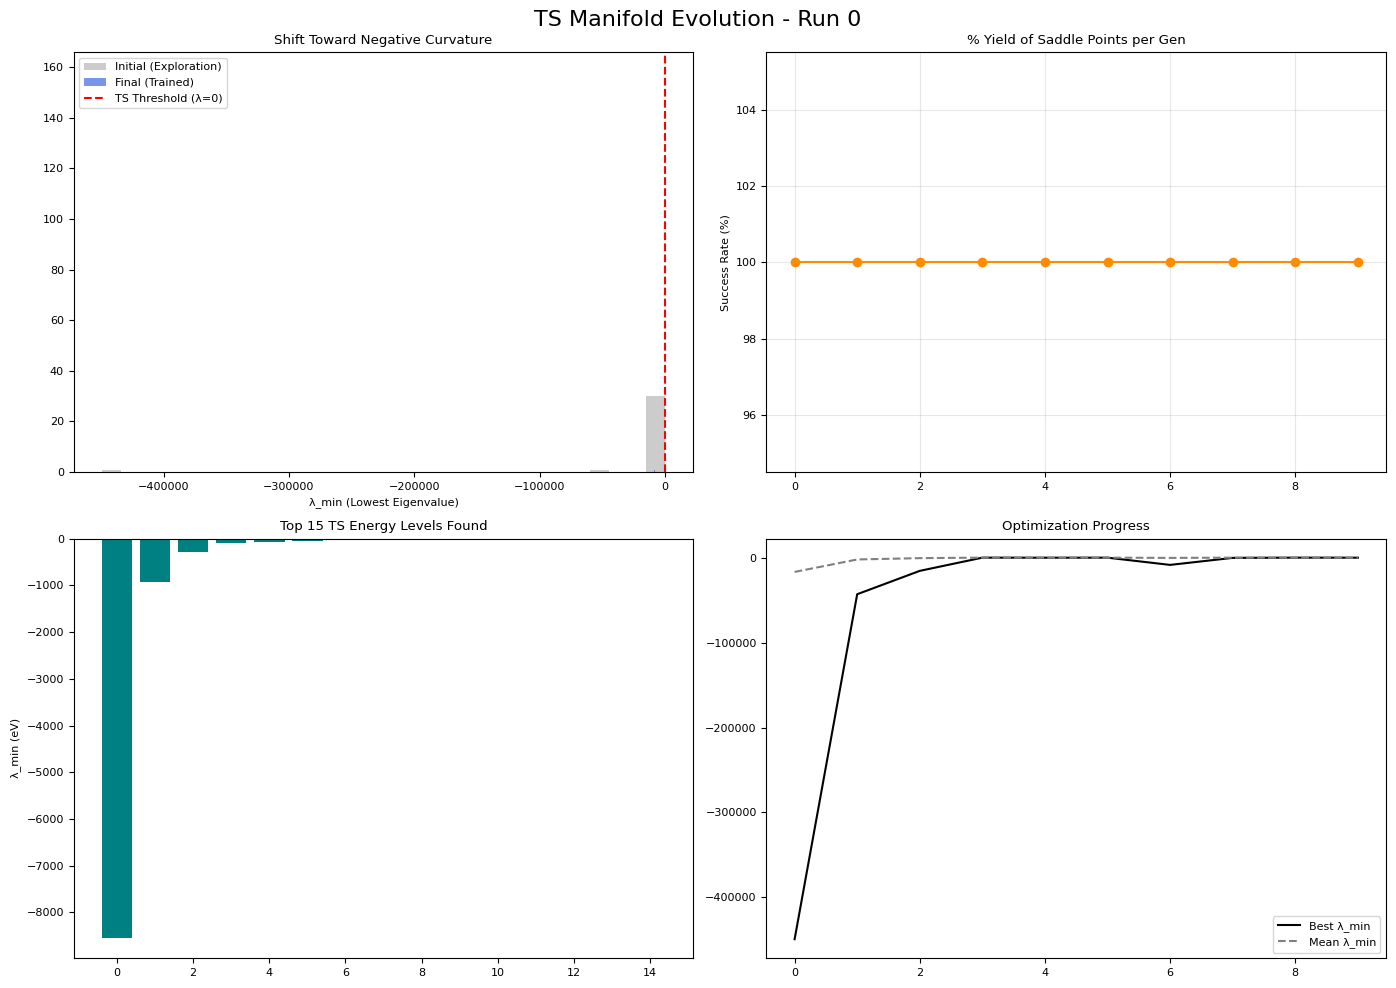

In [20]:
# Analyze ES convergence and minima found
#h5_file = "output/LJ-7_P-32_G-10_F-0.001_S-1000_U-2.337/ES_CHARLX-objective_evaluate_population_with_calc.h5"  # evo[0]  # First element of evo tuple is the h5_filename
#h5_file = "output/LJ-7_P-16_G-15_F-0.001_S-1000_U-2.337/ES_CHARLX-objective_minimize_eigenval.h5"
h5_file = evo[0]
run_id = 0 # evo[1]   # Second element is the run_id


convergence_analysis = analyze_ts_performance_robust(
    h5_file, 
    run_id=run_id,
    #obj_params=ts_optimizer.encode_params()
)

In [21]:
convergence_analysis = analyze_es_energy_groups(
    h5_file, 
    run_id=run_id
)

UnboundLocalError: cannot access local variable 'all_energies' where it is not associated with a value

In [22]:
import h5py
import numpy as np
import matplotlib.pyplot as plt
from typing import Callable, Dict, List, Optional

from ase.io.jsonio import decode

from util import (
    init_calc,
    solutions_to_atoms_list,
    calc_atoms_list,
    get_potential_energy,
    check_saddle_point,
)


def analyze_es_results(
    h5_filename: str,
    run_id: int = 0,
    last_gen_percent: float = 0.25,
    obj_params: Optional[dict] = None,
    energy_tolerance: float = 0.01,
    extra_metrics: Optional[Dict[str, Callable]] = None,
    plot: bool = True,
):
    """
    General purpose analysis of ES runs saved by run_evo().

    Parameters
    ----------
    h5_filename : str
        HDF5 file from run_evo
    run_id : int
    last_gen_percent : float
        fraction of final generations to analyze (0.25 = last 25%)
    obj_params : dict
        if provided -> build Atoms + compute real energies + saddle analysis
    energy_tolerance : float
        grouping threshold for energies
    extra_metrics : dict[str, callable]
        custom metrics applied to each Atoms
        each function must take (atoms) and return scalar
    plot : bool

    Returns
    -------
    dict with all computed results
    """

    if extra_metrics is None:
        extra_metrics = {}

    # =========================================================
    # 1) LOAD LAST GENERATIONS
    # =========================================================
    with h5py.File(h5_filename, "r") as f:

        run_group = f[f"run_{run_id}"]
        gen_keys = sorted(
            [k for k in run_group.keys() if k.startswith("gen_")],
            key=lambda x: int(x.split("_")[1]),
        )

        n_total = len(gen_keys)
        n_keep = max(1, int(np.ceil(n_total * last_gen_percent)))

        selected = gen_keys[-n_keep:]

        print(f"\nAnalyzing last {n_keep}/{n_total} generations: {selected[0]} → {selected[-1]}")

        all_samples = []
        all_fitness = []
        best_per_gen = []

        for g in selected:
            grp = run_group[g]
            samples = grp["samples"][:]
            fitness = grp["fitness"][:]

            all_samples.append(samples)
            all_fitness.extend(fitness)
            best_per_gen.append(np.max(fitness))

    all_samples = np.concatenate(all_samples, axis=0)
    all_fitness = np.array(all_fitness)

    all_fitness = np.clip(all_fitness, a_min=-1, a_max=20)

    # =========================================================
    # 2) FITNESS STATS
    # =========================================================
    print("\nFitness summary:")
    print("  mean:", np.mean(all_fitness))
    print("  std :", np.std(all_fitness))
    print("  best:", np.max(all_fitness))
    print("  worst:", np.min(all_fitness))

    results = {
        "fitness": all_fitness,
        "best_per_gen": best_per_gen,
    }

    # =========================================================
    # 3) STRUCTURE-BASED ANALYSIS
    # =========================================================
    if obj_params is not None:

        founder_atoms = decode(obj_params["founder_atoms"])
        fixed_atoms = decode(obj_params["fixed_atoms"])
        free_atoms = decode(obj_params["free_atoms"])

        frozen_atoms = (
            decode(obj_params["frozen_atoms"])
            if obj_params.get("frozen_atoms") is not None
            else None
        )

        calc = init_calc(obj_params["calc"], obj_params["device"])

        atoms_list = solutions_to_atoms_list(
            solutions=all_samples,
            founder_atoms=founder_atoms,
            fixed_atoms=fixed_atoms,
            fixed_indices=obj_params["fixed_indices"],
            free_atoms=free_atoms,
            frozen_atoms=frozen_atoms,
            frozen_indices=obj_params.get("frozen_indices", []),
            calc=calc,
        )

        # -----------------------
        # Energies
        # -----------------------
        energies = calc_atoms_list(
            atoms_list,
            func=get_potential_energy,
            desc="Energy",
            multiproc=obj_params["multiproc"],
            n_proc=obj_params["n_proc"],
            progress_bar=obj_params["progress_bar"],
            kwargs={},
        )

        energies = np.array(energies)
        results["energies"] = energies

        # -----------------------
        # Energy groups
        # -----------------------
        energy_groups = []
        order = np.argsort(energies)

        for idx in order:
            e = energies[idx]
            placed = False
            for gE, inds in energy_groups:
                if abs(e - gE) < energy_tolerance:
                    inds.append(idx)
                    placed = True
                    break
            if not placed:
                energy_groups.append([e, [idx]])

        results["energy_groups"] = energy_groups

        print(f"\nEnergy groups found: {len(energy_groups)}")

        for rank, (energy, indices) in enumerate(energy_groups, 1):
            count = len(indices)
            frequency = count / len(all_fitness) * 100
            print(f"{rank:<6} {energy:<18.6f} {count:<8} {frequency:>6.2f}%")

        # -----------------------
        # Saddle analysis
        # -----------------------
        print("Running saddle point diagnostics...")

        saddle_data = calc_atoms_list(
            atoms_list,
            func=check_saddle_point,
            desc="Saddle",
            multiproc=obj_params["multiproc"],
            n_proc=obj_params["n_proc"],
            progress_bar=obj_params["progress_bar"],
            kwargs={},
        )

        lowest_eigs = np.array([d["lowest_eval"] for d in saddle_data])
        saddle_mask = np.array([d["is_saddle_point"] for d in saddle_data])

        results["lowest_eigenvalues"] = lowest_eigs
        results["is_saddle"] = saddle_mask

        print("  saddle fraction:", saddle_mask.mean())

        # -----------------------
        # Extra user metrics
        # -----------------------
        for name, func in extra_metrics.items():
            print(f"Computing extra metric: {name}")
            metric_vals = calc_atoms_list(
                atoms_list,
                func=func,
                desc=name,
                multiproc=obj_params["multiproc"],
                n_proc=obj_params["n_proc"],
                progress_bar=obj_params["progress_bar"],
                kwargs={},
            )
            results[name] = np.array(metric_vals)

    # =========================================================
    # 4) PLOTS
    # =========================================================
    if plot:

        fig, axes = plt.subplots(2, 2, figsize=(12, 9))

        # fitness hist
        axes[0, 0].hist(all_fitness, bins=30)
        axes[0, 0].set_title("Fitness distribution")

        # convergence
        axes[0, 1].plot(best_per_gen, "o-")
        axes[0, 1].set_title("Best per generation")

        if "energies" in results:
            axes[1, 0].hist(results["energies"], bins=30)
            axes[1, 0].set_title("Energy distribution")

        if "lowest_eigenvalues" in results:
            axes[1, 1].hist(results["lowest_eigenvalues"], bins=30)
            axes[1, 1].set_title("Lowest Hessian eigenvalues")

        plt.tight_layout()
        plt.show()

    return results


Analyzing last 1/10 generations: gen_9 → gen_9

Fitness summary:
  mean: 12.070578211430892
  std : 4.441228949014951
  best: 20.0
  worst: 2.332528660310545


Energy: 100%|██████████| 32/32 [00:00<00:00, 669.01it/s]



Energy groups found: 30
1      -9.352912          1          3.12%
2      -8.178648          1          3.12%
3      -7.906528          1          3.12%
4      -7.718759          1          3.12%
5      -7.324365          1          3.12%
6      -7.238508          1          3.12%
7      -6.309539          1          3.12%
8      -5.966657          1          3.12%
9      -5.906118          1          3.12%
10     -5.742723          1          3.12%
11     -5.367168          2          6.25%
12     -5.314544          1          3.12%
13     -5.174322          2          6.25%
14     -5.029471          1          3.12%
15     -4.958087          1          3.12%
16     -4.825333          1          3.12%
17     -4.796826          1          3.12%
18     -4.652464          1          3.12%
19     -4.445755          1          3.12%
20     -4.366679          1          3.12%
21     -4.199108          1          3.12%
22     -4.043918          1          3.12%
23     -3.973754          1  

Saddle: 100%|██████████| 32/32 [00:01<00:00, 22.79it/s]



  saddle fraction: 0.0


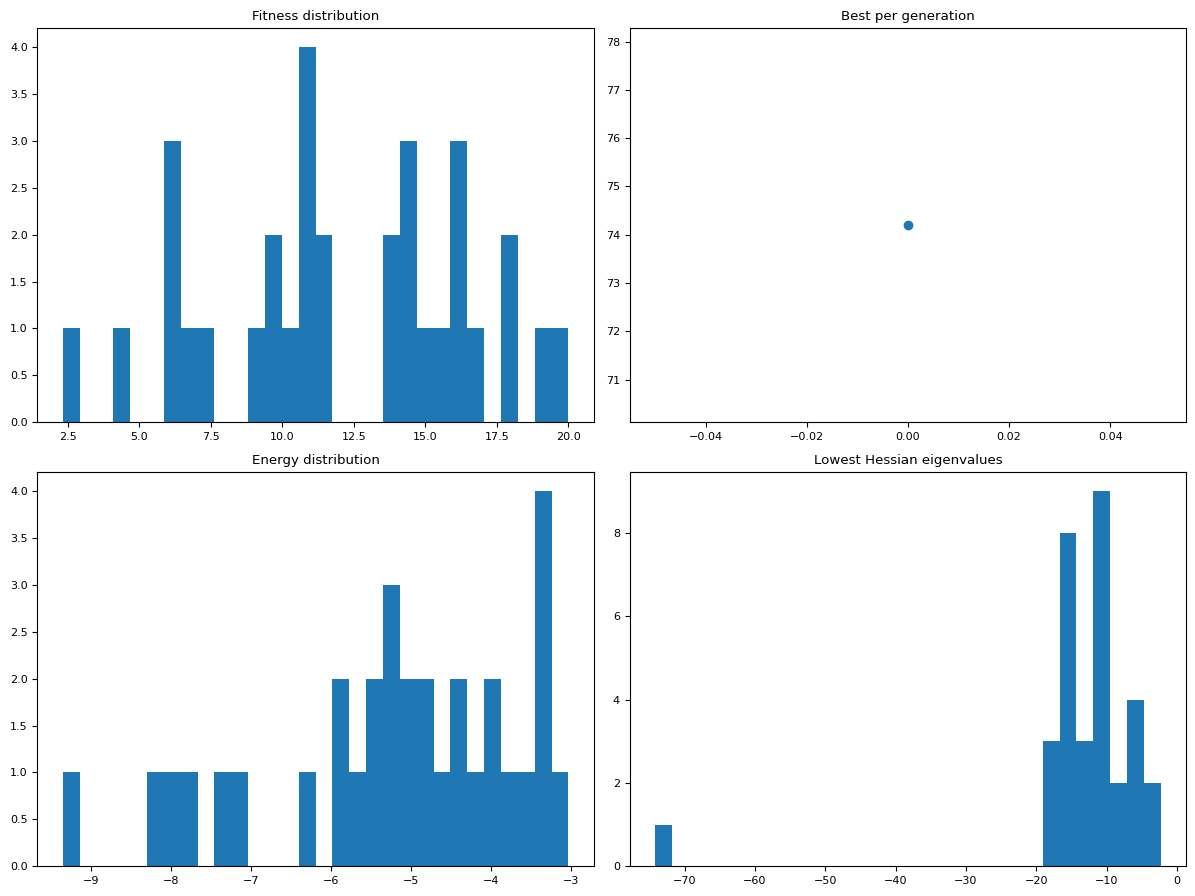

In [23]:
results = analyze_es_results(
    h5_filename=h5_file,
    run_id=0,
    last_gen_percent=0.1,
    obj_params=ts_optimizer.encode_params(),
    energy_tolerance=0.01,
    #extra_metrics={
    #    "n_atoms": lambda a: len(a),
    #    "com_z": lambda a: a.get_center_of_mass()[2],
    #},
)


Analyzing last 8/15 generations: gen_7 → gen_14

Fitness summary:
  mean: 4.75414515600306
  std : 5.552530775102249
  best: 16.061305888781956
  worst: -1.0


Energy:   0%|          | 0/128 [00:00<?, ?it/s]/opt/anaconda3/envs/cx/lib/python3.12/site-packages/e3nn/o3/_wigner.py:10: UserWarning: Environment variable TORCH_FORCE_NO_WEIGHTS_ONLY_LOAD detected, since the`weights_only` argument was not explicitly passed to `torch.load`, forcing weights_only=False.
  _Jd, _W3j_flat, _W3j_indices = torch.load(os.path.join(os.path.dirname(__file__), 'constants.pt'))
/opt/anaconda3/envs/cx/lib/python3.12/site-packages/e3nn/o3/_wigner.py:10: UserWarning: Environment variable TORCH_FORCE_NO_WEIGHTS_ONLY_LOAD detected, since the`weights_only` argument was not explicitly passed to `torch.load`, forcing weights_only=False.
  _Jd, _W3j_flat, _W3j_indices = torch.load(os.path.join(os.path.dirname(__file__), 'constants.pt'))
/opt/anaconda3/envs/cx/lib/python3.12/site-packages/e3nn/o3/_wigner.py:10: UserWarning: Environment variable TORCH_FORCE_NO_WEIGHTS_ONLY_LOAD detected, since the`weights_only` argument was not explicitly passed to `torch.load`, forcing wei

cuequivariance or cuequivariance_torch is not available. Cuequivariance acceleration will be disabled.
cuequivariance or cuequivariance_torch is not available. Cuequivariance acceleration will be disabled.
cuequivariance or cuequivariance_torch is not available. Cuequivariance acceleration will be disabled.
cuequivariance or cuequivariance_torch is not available. Cuequivariance acceleration will be disabled.
cuequivariance or cuequivariance_torch is not available. Cuequivariance acceleration will be disabled.
cuequivariance or cuequivariance_torch is not available. Cuequivariance acceleration will be disabled.
cuequivariance or cuequivariance_torch is not available. Cuequivariance acceleration will be disabled.
cuequivariance or cuequivariance_torch is not available. Cuequivariance acceleration will be disabled.
cuequivariance or cuequivariance_torch is not available. Cuequivariance acceleration will be disabled.
cuequivariance or cuequivariance_torch is not available. Cuequivariance a

Energy: 100%|██████████| 128/128 [00:28<00:00,  4.46it/s]




Energy groups found: 32
1      -15.444734         12         9.38%
2      -15.319864         4          3.12%
3      -15.283421         15        11.72%
4      -15.097846         1          0.78%
5      -15.033384         7          5.47%
6      -14.951088         2          1.56%
7      -14.940583         2          1.56%
8      -14.816400         3          2.34%
9      -14.596946         20        15.62%
10     -14.568061         2          1.56%
11     -14.548573         4          3.12%
12     -14.245658         1          0.78%
13     -14.043807         1          0.78%
14     -13.929783         1          0.78%
15     -13.909496         1          0.78%
16     -13.807503         1          0.78%
17     -13.721320         1          0.78%
18     -13.696117         1          0.78%
19     -13.606733         1          0.78%
20     -13.557971         1          0.78%
21     -13.532669         1          0.78%
22     -13.517835         1          0.78%
23     -13.494394         1  

...

cuequivariance or cuequivariance_torch is not available. Cuequivariance acceleration will be disabled.


/opt/anaconda3/envs/cx/lib/python3.12/site-packages/e3nn/o3/_wigner.py:10: UserWarning: Environment variable TORCH_FORCE_NO_WEIGHTS_ONLY_LOAD detected, since the`weights_only` argument was not explicitly passed to `torch.load`, forcing weights_only=False.
  _Jd, _W3j_flat, _W3j_indices = torch.load(os.path.join(os.path.dirname(__file__), 'constants.pt'))
/opt/anaconda3/envs/cx/lib/python3.12/site-packages/e3nn/o3/_wigner.py:10: UserWarning: Environment variable TORCH_FORCE_NO_WEIGHTS_ONLY_LOAD detected, since the`weights_only` argument was not explicitly passed to `torch.load`, forcing weights_only=False.
  _Jd, _W3j_flat, _W3j_indices = torch.load(os.path.join(os.path.dirname(__file__), 'constants.pt'))
/opt/anaconda3/envs/cx/lib/python3.12/site-packages/e3nn/o3/_wigner.py:10: UserWarning: Environment variable TORCH_FORCE_NO_WEIGHTS_ONLY_LOAD detected, since the`weights_only` argument was not explicitly passed to `torch.load`, forcing weights_only=False.
  _Jd, _W3j_flat, _W3j_indices

cuequivariance or cuequivariance_torch is not available. Cuequivariance acceleration will be disabled.
cuequivariance or cuequivariance_torch is not available. Cuequivariance acceleration will be disabled.
cuequivariance or cuequivariance_torch is not available. Cuequivariance acceleration will be disabled.
cuequivariance or cuequivariance_torch is not available. Cuequivariance acceleration will be disabled.
cuequivariance or cuequivariance_torch is not available. Cuequivariance acceleration will be disabled.
cuequivariance or cuequivariance_torch is not available. Cuequivariance acceleration will be disabled.
cuequivariance or cuequivariance_torch is not available. Cuequivariance acceleration will be disabled.
cuequivariance or cuequivariance_torch is not available. Cuequivariance acceleration will be disabled.
cuequivariance or cuequivariance_torch is not available. Cuequivariance acceleration will be disabled.
cuequivariance or cuequivariance_torch is not available. Cuequivariance a

Saddle: 100%|██████████| 128/128 [00:25<00:00,  5.00it/s]



  saddle fraction: 0.484375


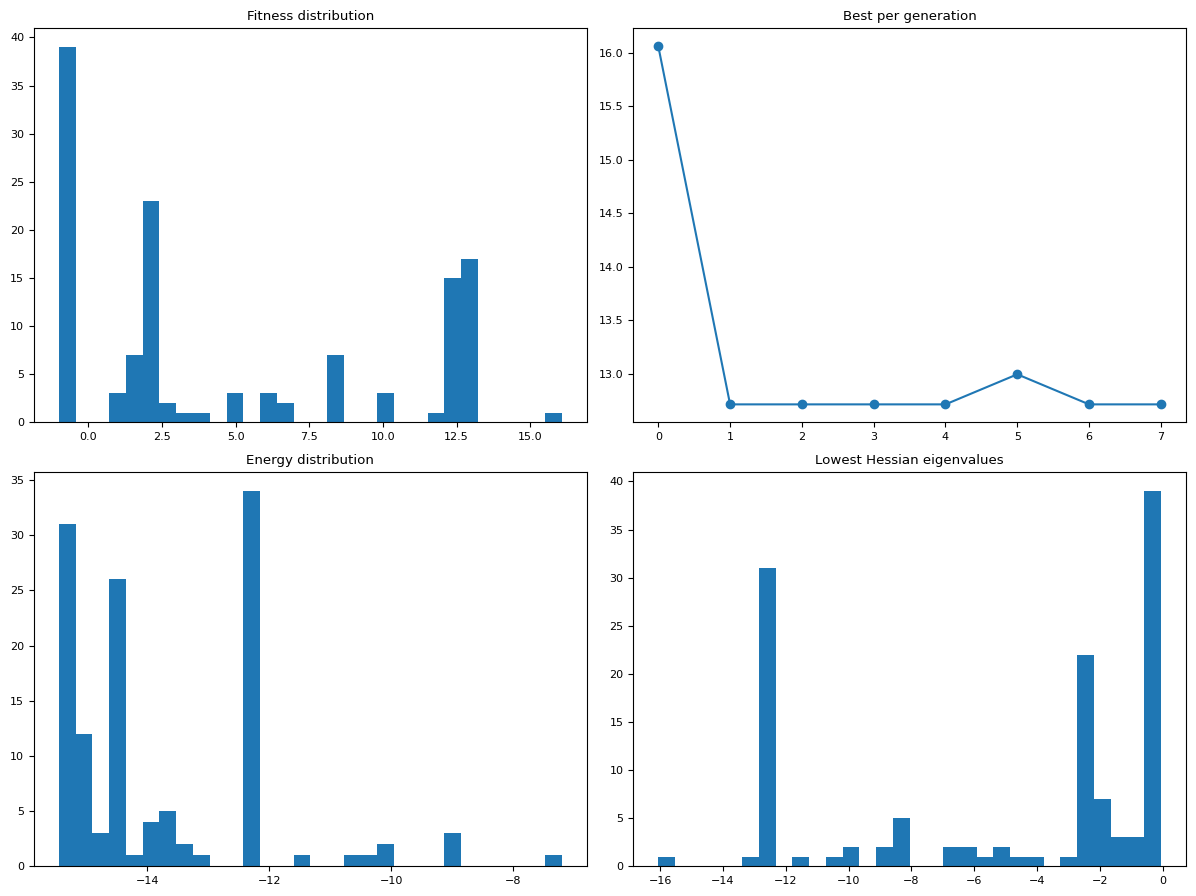

In [43]:
results = analyze_es_results(
    h5_filename="output/LJ-7_P-16_G-15_F-0.001_S-500_U-2.337/ES_CHARLX-objective_minimize_eigenval.h5",
    run_id=0,
    last_gen_percent=0.5,
    obj_params=ts_optimizer.encode_params(),
    energy_tolerance=0.01,
    #extra_metrics={
    #    "n_atoms": lambda a: len(a),
    #    "com_z": lambda a: a.get_center_of_mass()[2],
    #},
)